# **Tweet Sentiment Analysis with Fine-tune BERT**

### **Assignment 6a - Natural Language Processing - MSc. Computer Science, AUE[2025-2026]**

> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

> Electra Papadopoulou, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> elec.papadopoulou@aueb.gr

> Leonidas Kontogiannis, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> leo.kontogiannis@aueb.gr

## **Text Classification with Fine-tune BERTs**

In [ ]:
%pip install matplotlib seaborn nltk scikit-learn gensim numpy torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.1 MB/s eta 0:00:00


## **Imports**

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [ ]:
os.environ["KAGGLE_USERNAME"] = "" #add your own username
os.environ["KAGGLE_KEY"] = "" # add your own key

In [ ]:
!pip install -q kaggle
DATA_DIR = "/content/data"
!mkdir -p $DATA_DIR

!kaggle competitions download -c twitter-sentiment-analysis2 -p $DATA_DIR --force
!unzip -qo "$DATA_DIR/twitter-sentiment-analysis2.zip" -d $DATA_DIR

!ls -lh $DATA_DIR


  0% 0.00/14.6M [00:00<?, ?B/s]
100% 14.6M/14.6M [00:00<00:00, 345MB/s]
total 48M
-rw-r--r-- 1 root root  25M Nov 28  2019 test.csv
-rw-r--r-- 1 root root 8.3M Nov 28  2019 train.csv
-rw-r--r-- 1 root root  15M Nov 28  2019 twitter-sentiment-analysis2.zip


In [ ]:
try:
    df = pd.read_csv("/content/data/train.csv")
except UnicodeDecodeError:
    df = pd.read_csv("/content/data/train.csv", encoding="ISO-8859-1")

print("Loaded CSV successfully.")
print(df.shape)
df.head()

Loaded CSV successfully.
(99989, 3)


,ItemID,Sentiment,SentimentText
0,1,0,is so sad for my APL frie...
1,2,0,I missed the New Moon trail...
2,3,1,omg its already 7:30 :O
3,4,0,.. Omgaga. Im sooo im gunna CRy. I'...
4,5,0,i think mi bf is cheating on me!!! ...


In [ ]:
# Display basic info
print("Full dataset shape:", df.shape)
print(df['Sentiment'].value_counts())

Full dataset shape: (99989, 3)
Sentiment
1    56457
0    43532
Name: count, dtype: int64


### **Exploring the Dataset**

In [ ]:
x, y = df['SentimentText'], df['Sentiment']
print(len(x))
print(len(y))

99989
99989


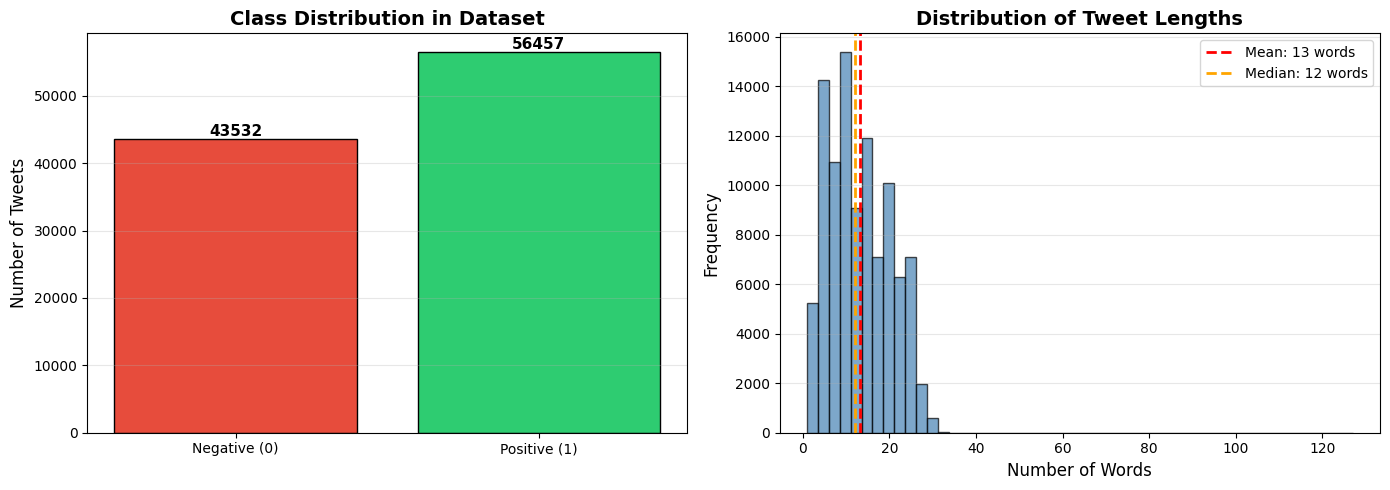

DATASET SUMMARY
Total tweets: 99989
Negative tweets: 43532 (43.5%)
Positive tweets: 56457 (56.5%)

Review Length Statistics:
  Min length: 1 words
  Max length: 127 words
  Mean length: 13.3 words
  Median length: 12.0 words
  Std deviation: 7.0 words


In [ ]:
import matplotlib.pyplot as plt

# Plot 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_counts = np.bincount(y)
axes[0].bar(['Negative (0)', 'Positive (1)'], class_counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_ylabel('Number of Tweets', fontsize=12)
axes[0].set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
# Add count labels on bars
for i, count in enumerate(class_counts):
    axes[0].text(i, count + 20, str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Tweet Length Distribution
tweet_lengths = [len(str(tweet).split()) for tweet in x]
axes[1].hist(tweet_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(tweet_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(tweet_lengths):.0f} words')
axes[1].axvline(np.median(tweet_lengths), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(tweet_lengths):.0f} words')
axes[1].set_xlabel('Number of Words', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Tweet Lengths', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Total tweets: {len(x)}")
print(f"Negative tweets: {class_counts[0]} ({class_counts[0]/len(x)*100:.1f}%)")
print(f"Positive tweets: {class_counts[1]} ({class_counts[1]/len(x)*100:.1f}%)")
print(f"\nReview Length Statistics:")
print(f"  Min length: {min(tweet_lengths)} words")
print(f"  Max length: {max(tweet_lengths)} words")
print(f"  Mean length: {np.mean(tweet_lengths):.1f} words")
print(f"  Median length: {np.median(tweet_lengths):.1f} words")
print(f"  Std deviation: {np.std(tweet_lengths):.1f} words")
print("="*60)

###  **Preprocess dataset**

In [ ]:
!python -m spacy download en_core_web_sm -q

In [ ]:
import spacy
import re
from tqdm import tqdm

# Load spaCy model
nlp = spacy.load("en_core_web_sm", disable=["ner","parser"])
# disabling parser and ner may speed up processing since you only need POS + lemma

docs = []
symbol_word_pattern = re.compile(r'\s*[\@\#\&][^\s]+')
html_entity_pattern = re.compile(r'&[a-z]+;')
url_pattern = re.compile(r'https?://\S+|www\.\S+')


for doc_text in tqdm(x):
    # Remove symbol prefix words
    doc_clean = symbol_word_pattern.sub(' ', doc_text)
    # Remove HTML entities
    doc_clean = html_entity_pattern.sub(' ', doc_clean)
    #Remove URLs
    doc_clean = url_pattern.sub(' ', doc_clean)
    # Remove non-word characters (punctuation etc)
    # doc_clean = re.sub(r'\W', ' ', str(doc_clean))
    # Remove single characters (optional)
    #doc_clean = re.sub(r'\s+[a-zA-Z]\s+', ' ', doc_clean)
    # Collapse multiple spaces
    doc_clean = re.sub(r'\s+', ' ', doc_clean, flags=re.I)
    # Lowercase
    doc_clean = doc_clean.lower().strip()

    # Process with spaCy
    doc = nlp(doc_clean)
    tokens = []
    for token in doc:
        tokens.append(token.lemma_)
    # Reconstruct document string
    docs.append(" ".join(tokens))

print("\nOriginal tweet text:\n{}".format(x[0]))
print("\nFiltered tweet text:\n{}".format(docs[0]))
print("\nLabel:\n", y[0])

100%|██████████| 99989/99989 [10:13<00:00, 163.06it/s]


Original tweet text:
                     is so sad for my APL friend.............

Filtered tweet text:
be so sad for my apl friend .............

Label:
 0


In [ ]:
import random

for i in range(10):
    idx = random.randint(0, len(x) - 1)
    print(f"\n===== Sample {i+1} (index {idx}) =====")
    print("\nOriginal tweet text:\n{}".format(x[idx]))
    print("\nFiltered tweet text:\n{}".format(docs[idx]))
    print("\nLabel:\n{}".format(y[idx]))



===== Sample 1 (index 20956) =====

Original tweet text:
@1AdrianNeal working . . 6 am to 2 :3O pm  . so im about to turn in ! ttyL k

Filtered tweet text:
work . . 6 be to 2 : 3o pm . so I m about to turn in ! ttyl k

Label:
0

===== Sample 2 (index 89863) =====

Original tweet text:
@babygirlparis Hey I seen you @ the Awards,, looking GREAT as ALWAYS!!! BFF &lt;&lt; LOL &gt;&gt; XOXO 

Filtered tweet text:
hey I see you @ the award , , look great as always ! ! ! bff lol xoxo

Label:
1

===== Sample 3 (index 58717) =====

Original tweet text:
@BeckLovesKyle you know what I will trade you.  You can have the summer if I can have the winter 

Filtered tweet text:
you know what I will trade you . you can have the summer if I can have the winter

Label:
1

===== Sample 4 (index 59893) =====

Original tweet text:
@BellaSkyy Hi there    I'm about to go pick up my baby : D .... Been bored waiting , LOL!!

Filtered tweet text:
hi there I be about to go pick up my baby : d .... be bore wait , 

### **Split dataset into train (70%) , test (15%) and dev (15%)**

In [ ]:
from sklearn.model_selection import train_test_split

# Split into train (70%) and temp (30%)
x_train, x_temp, y_train, y_temp = train_test_split(
    docs,
    y,
    test_size=0.30,
    stratify=y,          # preserve class proportions
    random_state=2025
)

# Split temp (30%) into dev (15%) and test (15%)
x_dev, x_test, y_dev, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,      # 50% of 30% = 15%
    stratify=y_temp,
    random_state=2025
)

# Confirm split sizes
print(f"Train: {len(x_train)}  Dev: {len(x_dev)}  Test: {len(x_test)}")

# Verify label balance
for name, labels in [("Train", y_train), ("Dev", y_dev), ("Test", y_test)]:
    print(f"\n{name} distribution:")
    print(pd.Series(labels).value_counts(normalize=True).round(3))


Train: 69992  Dev: 14998  Test: 14999

Train distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64

Dev distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64

Test distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64


## **From Exercise 2: Feature extraction (TF-IDF n-gram features)**



In this step, we convert the preprocessed text data into numerical feature vectors using the **TF-IDF (Term Frequency–Inverse Document Frequency)** representation. TF-IDF measures how important a word is in a document relative to the entire dataset, allowing the model to emphasize informative tokens while discounting common and less meaningful ones.

We apply the `TfidfVectorizer` with the following configuration parameters:

- **n-gram range = (1, 3):** Extracts unigrams, bigrams, and trigrams. This allows the model to capture individual words as well as short phrases that may express sentiment (e.g., *"not good"*, *"very happy"*, *"love this"*).
- **max_features = 30,000:** Limits the vocabulary to the most informative 30,000 terms for computational efficiency.
- **stop_words = 'english':** Removes common non-informative English words (e.g., "the", "and", "is").
- **sublinear_tf = True:** Applies logarithmic scaling to term frequencies, reducing the influence of repeated words.

The resulting TF-IDF vectors are represented as **sparse matrices**, where only non-zero weights are stored to minimize memory usage. After transformation, we inspect:
1. The vocabulary learned by the vectorizer.
2. The dimensionality of the training and test feature matrices.
3. The most influential (highest-weighted) tokens in a sample tweet, which provides interpretability regarding how the model represents text input.

In [ ]:
#Feature extraction (TF-IDF n-gram features)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Use unigram & bi-gram tf*idf features
#vectorizer = TfidfVectorizer(ngram_range = (1, 2),max_features = 5000, sublinear_tf = True)

# Use unigram & bi-gram & tri-gram tf*idf features
vectorizer = TfidfVectorizer(ngram_range = (1, 3),max_features = 30000, sublinear_tf = True, stop_words='english')

# Reuse the same TF-IDF vectorizer for all splits
x_train_tfidf = vectorizer.fit_transform(x_train)
x_dev_tfidf   = vectorizer.transform(x_dev)
x_test_tfidf  = vectorizer.transform(x_test)

print([vectorizer.get_feature_names_out()[i] for i in range(1, 50, 5)]) # Shows the learned vocabulary
print(len(vectorizer.get_feature_names_out())) # Number of features == 30000


# Low-dimensional dense representations for MLP
svd_mlp = TruncatedSVD(n_components=500, random_state=2025)
X_train_svd = svd_mlp.fit_transform(x_train_tfidf)
X_dev_svd   = svd_mlp.transform(x_dev_tfidf)
X_test_svd  = svd_mlp.transform(x_test_tfidf)

print("Done Creating SVD")

['000', '00am', '04', '09', '10 30', '10 hour', '10 minute', '10 year old', '100 real photo', '1000th']
30000
Done Creating SVD


In [ ]:
print(vectorizer.get_feature_names_out()[:50])  # show up to 50 features

['00' '000' '000 000' '000 follower' '000 follower bday' '000 people'
 '00am' '00pm' '01' '02' '03' '04' '05' '06' '07' '08' '09' '0_o' '10'
 '10 00' '10 000' '10 30' '10 cat' '10 clock' '10 clock night' '10 day'
 '10 hour' '10 just' '10 million' '10 million dollar' '10 min' '10 minute'
 '10 pm' '10 time' '10 work' '10 year' '10 year old' '100' '100 follower'
 '100 follower day' '100 real' '100 real photo' '100 time' '1000'
 '1000 follower' '1000 time' '1000th' '100th' '100th update' '101']


In [ ]:
print(f'Shape of training data: {x_train_tfidf.shape}')
print(f'Shape of test data: {x_test_tfidf.shape}')

# TFIDF Vectorizer returns Sparse matrix structures --> Saves only the cells which are not zero (be memory efficient), so it can not be printed directly
print(x_test_tfidf.todense()[0, :5000])

Shape of training data: (69992, 30000)
Shape of test data: (14999, 30000)
[[0. 0. 0. ... 0. 0. 0.]]


In [ ]:
doc_index = 0
doc_vector = x_test_tfidf[doc_index].todense()
features = vectorizer.get_feature_names_out()

# Build a DataFrame: each word → its TF-IDF weight in this document
df_doc = pd.DataFrame({
    'Feature': features,
    'TFIDF': doc_vector.tolist()[0]  # convert to 1D list
})

# Show only non-zero entries (words that actually appear in the tweet)
df_nonzero = df_doc[df_doc['TFIDF'] > 0].sort_values(by='TFIDF', ascending=False)

print(f"Number of non-zero features in this document: {len(df_nonzero)}")
print(df_nonzero.head())  # top weighted words


Number of non-zero features in this document: 4
      Feature     TFIDF
24785   spill  0.584581
8808    homie  0.560398
4995       dm  0.432897
27063    true  0.396004


### **Model Training: Baseline and Logistic Regression Classifiers**

In this section, we compare three different classification approaches for tweet sentiment prediction. The aim is to evaluate how different feature representations (TF-IDF vs. Boolean presence) and model assumptions impact classification performance.

#### 1. **Majority Baseline Classifier**
The baseline model predicts the sentiment class that appears most frequently in the training set.  
This provides a **lower-bound performance benchmark**. A good classifier should significantly outperform this baseline.

#### 2. **Logistic Regression with TF-IDF and Character-Level Features**
This model uses a **hybrid feature representation**:
- **Word-level TF-IDF** features (unigrams, bigrams, trigrams)
- **Character-level n-grams** to capture stylistic cues, misspellings, slang, and emojis often found in tweets.

Additionally, we apply:
- **Feature selection using Mutual Information (`SelectKBest`)** to keep the most informative 30,000 features.
- **Class-balanced Logistic Regression** to counteract class imbalance.

This model is expected to capture both semantic and stylistic sentiment signals.

#### 3. **Logistic Regression with Boolean Bag-of-Words Features**
This model uses a **binary CountVectorizer** that records only the *presence or absence* of terms.  
This representation is simpler and may reduce noise, but it ignores term frequency and relative importance of words.

In [ ]:
# === Two Pipelines: Baseline, Logistic Regression (TF-IDF) ===
import time
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# 1) Majority Baseline (most_frequent)
baseline = Pipeline([
    ("classifier", DummyClassifier(strategy="most_frequent", random_state=2025)),
])

# 2) Logistic Regression (TF-IDF)
vectorizer = FeatureUnion([
    ('word', TfidfVectorizer(ngram_range = (1, 3),max_features = 30000, stop_words='english', sublinear_tf = True)),
    # Character features help with misspellings, slang, and emojis.
    ('char', TfidfVectorizer(analyzer='char', ngram_range=(3,5), max_features=20000))
])

lr_tfidf = Pipeline([
    ('vectorizer', vectorizer),
    ('selector', SelectKBest(mutual_info_classif, k=30000)),
    ('classifier', LogisticRegression(max_iter=1000, n_jobs=-1, class_weight='balanced', C=1))
])

# Quick sanity fits + metrics
def quick_report(name, pipe, x_train, y_train, x_test, y_test):
    t0 = time.time()
    pipe.fit(x_train, y_train)
    dt = time.time() - t0
    ytr = pipe.predict(x_train)
    yte = pipe.predict(x_test)
    print(f"✓ {name} trained in {dt:.3f}s")
    print(f"  Train  Acc: {accuracy_score(y_train, ytr):.4f} | F1: {f1_score(y_train, ytr):.4f}")
    print(f"  Test   Acc: {accuracy_score(y_test, yte): .4f} | F1: {f1_score(y_test, yte): .4f}\n")
    return pipe

print("=== Evaluation ===")
baseline        = quick_report("Baseline",          baseline, x_train, y_train, x_test, y_test)
lr_tfidf        = quick_report("LR (TF-IDF)",       lr_tfidf, x_train, y_train, x_test, y_test)

trained_models = [
    ("Majority Baseline", baseline),
    ("TF-IDF+LR", lr_tfidf)
]


=== Evaluation ===
✓ Baseline trained in 0.002s
  Train  Acc: 0.5646 | F1: 0.7217
  Test   Acc:  0.5646 | F1:  0.7217

✓ LR (TF-IDF) trained in 463.413s
  Train  Acc: 0.8366 | F1: 0.8531
  Test   Acc:  0.7723 | F1:  0.7959



##  **Creating TF-IDF MLP of Exercise 3**

In [ ]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
class MLP_tf_idf(nn.Module):
    def __init__(self, input_dim=500, hidden_sizes=[256], dropout_prob=0.7):
        super().__init__()

        layers = []
        dim = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_prob))
            dim = h

        # Final layer: 2 classes (negative/positive)
        layers.append(nn.Linear(dim, 2))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

mlp_classifier = MLP_tf_idf()
print(mlp_classifier)

# Count the total number of parameters
total_params = sum(p.numel() for p in mlp_classifier.parameters())
print(f"Total number of parameters: {total_params}")

# Count the number of trainable parameters
trainable_params = sum(p.numel() for p in mlp_classifier.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {trainable_params}")

MLP_tf_idf(
  (model): Sequential(
    (0): Linear(in_features=500, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.7, inplace=False)
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)
Total number of parameters: 128770
Number of trainable parameters: 128770


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train_svd, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_dev_tensor = torch.tensor(X_dev_svd, dtype=torch.float32)
y_dev_tensor = torch.tensor(y_dev.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_svd, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [ ]:
batch_size = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor) # pairs each input vector with its label
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # divides it into mini-batches of 256 and reshuffles data every epoch (shuffle=True)

dev_dataset = TensorDataset(X_dev_tensor, y_dev_tensor)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False) #see whats best, shuffle=True or False

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) #see whats best, shuffle=True or False

## **Creating the final MLP model**

In [ ]:
from sklearn.metrics import f1_score

def train_final_model(hidden_sizes, dropout_prob, epochs, lr=0.001):
    model = MLP_tf_idf(hidden_sizes=hidden_sizes, dropout_prob=0.7).to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "dev_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "train_f1_score": [],
        "val_f1_score": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        all_train_preds = []
        all_train_labels = []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds_train = torch.argmax(logits, dim=1)
            all_train_preds.append(preds_train.cpu())
            all_train_labels.append(y_batch.cpu())

        # --- Training metrics ---
        train_preds_tensor = torch.cat(all_train_preds)
        train_labels_tensor = torch.cat(all_train_labels)
        train_acc = (train_preds_tensor == train_labels_tensor).float().mean().item()
        train_f1 = f1_score(train_labels_tensor, train_preds_tensor, average='macro')

        avg_train_loss = running_loss / len(train_loader)

        # --- Validation metrics ---
        model.eval()
        with torch.no_grad():
            dev_logits = model(X_dev_tensor.to(device))
            dev_loss = criterion(dev_logits, y_dev_tensor.to(device)).item()
            dev_preds = torch.argmax(dev_logits, dim=1).cpu()
            val_acc = (dev_preds == y_dev_tensor).float().mean().item()
            val_f1 = f1_score(y_dev, dev_preds, average='macro')

        # --- Append to history ---
        history["train_loss"].append(avg_train_loss)
        history["dev_loss"].append(dev_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        history["train_f1_score"].append(train_f1)
        history["val_f1_score"].append(val_f1)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss={avg_train_loss:.4f} | Dev Loss={dev_loss:.4f} | "
              f"Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | "
              f"Train F1={train_f1:.4f} | Val F1={val_f1:.4f}")

    return model, history



In [ ]:
best_model_mlp, history_mlp = train_final_model(
    hidden_sizes=[512],
    dropout_prob=0.7,
    epochs=26,
    lr=0.001
)

Epoch 1/26 | Train Loss=0.5883 | Dev Loss=0.5525 | Train Acc=0.6743 | Val Acc=0.7098 | Train F1=0.6416 | Val F1=0.6969
Epoch 2/26 | Train Loss=0.5435 | Dev Loss=0.5509 | Train Acc=0.7160 | Val Acc=0.7108 | Train F1=0.7039 | Val F1=0.6966
Epoch 3/26 | Train Loss=0.5395 | Dev Loss=0.5508 | Train Acc=0.7200 | Val Acc=0.7131 | Train F1=0.7077 | Val F1=0.7034
Epoch 4/26 | Train Loss=0.5362 | Dev Loss=0.5498 | Train Acc=0.7206 | Val Acc=0.7110 | Train F1=0.7089 | Val F1=0.6990
Epoch 5/26 | Train Loss=0.5338 | Dev Loss=0.5492 | Train Acc=0.7241 | Val Acc=0.7141 | Train F1=0.7124 | Val F1=0.7036
Epoch 6/26 | Train Loss=0.5303 | Dev Loss=0.5495 | Train Acc=0.7271 | Val Acc=0.7128 | Train F1=0.7157 | Val F1=0.6966
Epoch 7/26 | Train Loss=0.5279 | Dev Loss=0.5506 | Train Acc=0.7280 | Val Acc=0.7146 | Train F1=0.7165 | Val F1=0.7066
Epoch 8/26 | Train Loss=0.5250 | Dev Loss=0.5499 | Train Acc=0.7324 | Val Acc=0.7138 | Train F1=0.7212 | Val F1=0.7003
Epoch 9/26 | Train Loss=0.5218 | Dev Loss=0.5499

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

best_model_mlp.eval()
best_model_mlp.to("cpu")  # move to CPU for sklearn

# Dev predictions
with torch.no_grad():
    dev_logits = best_model_mlp(X_dev_tensor)
    dev_preds = torch.argmax(dev_logits, dim=1)

# Test predictions
with torch.no_grad():
    test_logits = best_model_mlp(X_test_tensor)
    test_preds = torch.argmax(test_logits, dim=1)

print(f"Dev Accuracy:  {accuracy_score(y_dev, dev_preds)*100:.2f}%")
print(f"Test Accuracy: {accuracy_score(y_test, test_preds)*100:.2f}%")

print("\nDev performance:")
print(classification_report(y_dev, dev_preds, target_names=['Negative', 'Positive'], digits=4))

print("\nTest performance:")
print(classification_report(y_test, test_preds, target_names=['Negative', 'Positive'], digits=4))


Dev Accuracy:  71.62%
Test Accuracy: 71.54%

Dev performance:
              precision    recall  f1-score   support

    Negative     0.7070    0.5946    0.6460      6530
    Positive     0.7215    0.8100    0.7632      8468

    accuracy                         0.7162     14998
   macro avg     0.7143    0.7023    0.7046     14998
weighted avg     0.7152    0.7162    0.7122     14998


Test performance:
              precision    recall  f1-score   support

    Negative     0.7079    0.5896    0.6433      6530
    Positive     0.7197    0.8124    0.7632      8469

    accuracy                         0.7154     14999
   macro avg     0.7138    0.7010    0.7033     14999
weighted avg     0.7145    0.7154    0.7110     14999



In [ ]:
best_model_mlp.eval()
best_model_mlp.to("cpu")

# --- Validation accuracy ---
y_pred_val = torch.argmax(best_model_mlp(X_dev_tensor), dim=1)
val_acc = accuracy_score(y_dev, y_pred_val)
print(f'Validation Accuracy: {val_acc*100:.2f}%')

# --- Test accuracy ---
y_pred_test = torch.argmax(best_model_mlp(X_test_tensor), dim=1)
test_acc = accuracy_score(y_test, y_pred_test)
print(f'Test Accuracy: {test_acc*100:.2f}%')


Validation Accuracy: 71.62%
Test Accuracy: 71.54%


## **Data Preprocessing for the RNN and CNN**

### Vocabulary building

In [ ]:
from collections import Counter

def build_vocab(texts, min_freq, max_vocab_size=None):
    # counte every word
    cnt = Counter()
    for doc in texts:
        for tok in doc.split():
            cnt[tok] += 1

    # special tokens
    specials = ["<pad>", "<unk>"]

    # remove infrequent words
    items = [w for w,f in cnt.most_common() if f >= min_freq]

    if max_vocab_size:
        items = items[:max_vocab_size - len(specials)]

    idx2str = specials + items
    str2idx = {w:i for i,w in enumerate(idx2str)}
    return str2idx, idx2str, cnt

# Build on train only
str2idx, idx2str, counter = build_vocab(x_train, min_freq=1, max_vocab_size=50000)
vocab_size = len(idx2str)
print("Vocab size:", vocab_size)
print("Top 20 tokens:", idx2str[2:22])

Vocab size: 39443
Top 20 tokens: ['I', 'be', '!', '.', ',', 'to', 'you', 'the', '?', 'not', 'a', 'it', 'have', 'do', 'and', 'that', '...', 'my', 'for', 'in']


In [ ]:
train_clean_x = []
train_clean_y = []

for text, label in zip(x_train, y_train):
    if text.strip() != "":
        train_clean_x.append(text)
        train_clean_y.append(label)

dev_clean_x = []
dev_clean_y = []

for text, label in zip(x_dev, y_dev):
    if text.strip() != "":
        dev_clean_x.append(text)
        dev_clean_y.append(label)

test_clean_x = []
test_clean_y = []

for text, label in zip(x_test, y_test):
    if text.strip() != "":
        test_clean_x.append(text)
        test_clean_y.append(label)

In [ ]:
tokenized_train = [tweet.split() for tweet in train_clean_x]
#tokenized_dev = [tweet.split() for tweet in x_dev]
#tokenized_text = [tweet.split() for tweet in x_test]

print(tokenized_train[:3])

print("Length:", len(tokenized_train))
print("Empty docs:", sum(1 for d in tokenized_train if len(d) == 0))

[['my', 'bag', 'steal', 'from', 'beneath', 'table', '@', 'pub', 'tonight', '.', 'it', 'have', 'all', 'my', 'stuff', 'in', 'it', '.', 'lot', 'of', 'bit', '.', 'kinda', 'know', 'how', 'u', 'feel', 'bout', 'diary'], ['aww', '.', 'I', 'be', 'glad', 'that', 'he', 'give', 'she', 'a', 'shoutout', '.', 'she', 'go', 'to', 'bed', 'like', '20', 'minute', 'too', 'early', '!', '!', '!', '!'], ['..', 'and', 'of', 'course', '...', 'I', 'have', 'access', 'to', 'my', 'halo', '3', 'mythic', 'map', 'pack', 're', '-', 'download', '..', 'but', 'bad', 'news', '..', 'not', 'the', 'legendary', 'map', 'pack', '...', 'ugh', '..', '600ms', '...']]
Length: 69715
Empty docs: 0


### Create word embeddings using the train dataset

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.7 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

EMB_DIM = 100

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=EMB_DIM,
    window=5,
    min_count=1,
    workers=-1,
    sg=1,          # 1 = skip-gram (better for rare/informal words), 0 = CBOW
    epochs=10
)

print("Word2Vec vocab size:", len(w2v_model.wv)) # # number of tokens in vocabulary
print(w2v_model.wv['happy'])     # try an example lookup

Word2Vec vocab size: 39441
[-9.8972367e-03 -9.2722382e-03  5.8333920e-03  9.8299198e-03
 -7.1276496e-03  3.9819549e-03  8.6080553e-03 -6.2030577e-03
 -4.2331610e-03  6.2131546e-03 -3.8250624e-03  6.7299865e-03
 -7.0787347e-03 -2.2851503e-03  5.2328170e-03  6.2291883e-03
  2.9586744e-03  5.3230167e-04  5.2966760e-03  7.2170151e-03
  7.3386384e-03  8.1931995e-03  3.8847995e-03 -6.7879353e-03
  6.9916607e-03 -1.2386394e-03 -2.2181976e-03  8.8652829e-03
  6.8575335e-03 -4.1045318e-03  4.6568131e-03 -6.9662845e-03
 -6.7587672e-03  7.4287462e-03 -7.9577806e-04 -9.9229375e-03
  6.7418446e-03  7.9033338e-03  2.7702164e-03 -6.4465418e-03
  1.4814138e-05 -1.7609894e-03 -1.3711405e-03  7.2757495e-03
 -5.1005743e-03 -9.8485379e-03  4.5062886e-03  5.7537924e-03
  5.3813052e-03 -8.0962693e-03  8.4944163e-03  2.8093886e-03
 -8.5122586e-04 -2.4791933e-03 -2.1195328e-03 -1.4243925e-03
  4.3527698e-03  7.3043583e-03  1.2716174e-04  2.5126755e-03
  5.5437803e-04 -6.1966274e-03  3.7118089e-03 -6.5833880e-

In [ ]:
import numpy as np

embedding_matrix = np.zeros((vocab_size, EMB_DIM), dtype=np.float32)

for idx, word in enumerate(idx2str):
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(EMB_DIM,))

embedding_layer = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=EMB_DIM,
    padding_idx=str2idx["<pad>"]
)

# load our custom matrix
embedding_layer.weight.data.copy_(torch.from_numpy(embedding_matrix))

embedding_layer.weight.requires_grad = True   # fine-tune

def tweet_to_vec(tokens, w2v_model, embedding_dim=EMB_DIM):
    vectors = []
    for token in tokens:
        if token in w2v_model.wv:
            vectors.append(w2v_model.wv[token])
    if len(vectors) == 0:
        # return zero vector if no tokens matched
        return np.zeros(embedding_dim, dtype=np.float32)
    return np.mean(vectors, axis=0)

### PyTorch Dataset + DataLoader

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

class TweetsSeqDataset(Dataset):
    def __init__(self, texts, labels, str2idx):
        """
        texts: list of cleaned strings (space-separated tokens)
        labels: list/array of ints (0..C-1)
        str2idx: dict token->index, with "<pad>" and "<unk>"
        """
        self.texts = texts
        self.labels = np.array(labels)
        self.str2idx = str2idx

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = self.texts[idx].split()
        indices = [self.str2idx.get(t, self.str2idx["<unk>"]) for t in tokens]
        if len(indices) == 0:
            # avoid zero-length sequences (replace with pad token index so collate handles it)
            indices = [self.str2idx["<pad>"]]
        return torch.tensor(indices, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

def collate_batch_pad(batch):
    """
    batch: list of (indices_tensor, label_tensor)
    returns:
      tokens_padded: (B, T) LongTensor
      lengths: (B,) LongTensor
      labels: (B,) LongTensor
    """
    tokens = [item[0] for item in batch]
    labels = torch.stack([item[1] for item in batch])
    lengths = torch.tensor([t.shape[0] for t in tokens], dtype=torch.long)
    tokens_padded = pad_sequence(tokens, batch_first=True, padding_value=str2idx["<pad>"])
    return tokens_padded, lengths, labels

In [ ]:
BATCH_SIZE = 256

train_ds = TweetsSeqDataset(train_clean_x, train_clean_y, str2idx)
dev_ds   = TweetsSeqDataset(dev_clean_x,   dev_clean_y,   str2idx)
test_ds  = TweetsSeqDataset(test_clean_x,  test_clean_y,  str2idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch_pad)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch_pad)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch_pad)

print("Samples:", len(train_ds), len(dev_ds), len(test_ds))

Samples: 69715 14929 14932


In [ ]:
import gc

# Free RAM
del w2v_model
gc.collect()

60

## **Creating the RNN Model of Exercise 4**

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, hidden_dim, attn_hidden_dim=None):
        """
        hidden_dim: dimension of BiRNN hidden states (per direction concatenated -> 2*hid)
        attn_hidden_dim: if provided, use a single hidden layer MLP for attention scores
        """
        super().__init__()
        if attn_hidden_dim is None:
            # single linear score: score = v^T tanh(W h + b)
            self.w = nn.Linear(hidden_dim, hidden_dim, bias=True)
            self.v = nn.Linear(hidden_dim, 1, bias=False)
            self.use_mlp = False
        else:
            # small MLP: h -> ReLU -> score
            self.mlp = nn.Sequential(
                nn.Linear(hidden_dim, attn_hidden_dim),
                nn.ReLU(),
                nn.Linear(attn_hidden_dim, 1)
            )
            self.use_mlp = True

    def forward(self, H, mask=None):
        """
        H: (B, T, hidden_dim)
        mask: (B, T) with 1 for token, 0 for pad (optional)
        Returns: context (B, hidden_dim) and attn_weights (B, T)
        """
        if self.use_mlp:
            scores = self.mlp(H).squeeze(-1)  # (B, T)
        else:
            x = torch.tanh(self.w(H))         # (B, T, hidden_dim)
            scores = self.v(x).squeeze(-1)    # (B, T)
        if mask is not None:
            # mask: 1 for valid, 0 for pad -> set pad scores to very negative
            scores = scores.masked_fill(mask == 0, -1e9)
        attn_weights = torch.softmax(scores, dim=-1)  # (B, T)
        # compute weighted sum
        attn_weights_unsq = attn_weights.unsqueeze(-1)  # (B, T, 1)
        context = torch.sum(H * attn_weights_unsq, dim=1)  # (B, hidden_dim)
        return context, attn_weights

In [ ]:
class BiLSTMWithAttention(nn.Module):
    def __init__(self, embedding_matrix, pad_idx, hidden_size=256, num_layers=2,
                 dropout=0.3, bidirectional=True, rnn_type='lstm', attn_hidden_dim=None,
                 fine_tune_embeddings=True, num_classes=2, emb_dropout=0.2):
        """
        embedding_matrix: numpy array [vocab_size, emb_dim]
        pad_idx: index used for padding (so embedding_layer padding_idx)
        hidden_size: LSTM hidden size per direction
        num_layers: stacked RNN layers
        bidirectional: True
        rnn_type: 'lstm' or 'gru'  (you requested LSTM)
        attn_hidden_dim: if None -> single dense attention as in slides; else small MLP with this hidden dim
        fine_tune_embeddings: whether to allow embedding updates
        num_classes: number of output classes
        """
        super().__init__()
        emb_weights = torch.tensor(embedding_matrix, dtype=torch.float)
        vocab_size, emb_dim = emb_weights.shape
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.embedding.weight.data.copy_(emb_weights)
        self.embedding.weight.requires_grad = fine_tune_embeddings

        self.emb_dropout = nn.Dropout(emb_dropout) if emb_dropout and emb_dropout>0 else nn.Identity()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        num_directions = 2 if bidirectional else 1

        if rnn_type.lower() == 'lstm':
            self.rnn = nn.LSTM(
                input_size=emb_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers>1 else 0.0,
                bidirectional=bidirectional
            )
        else:
            self.rnn = nn.GRU(
                input_size=emb_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers>1 else 0.0,
                bidirectional=bidirectional
            )

        # attention sees concatenated hidden states size = hidden_size * num_directions
        attn_in_dim = hidden_size * num_directions
        self.attention = SelfAttention(attn_in_dim, attn_hidden_dim)

        # classifier head
        self.classifier = nn.Sequential(
            nn.Linear(attn_in_dim, attn_in_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(attn_in_dim//2, num_classes)
        )

    def forward(self, tokens, lengths):
        """
        tokens: (B, T) LongTensor
        lengths: (B,) LongTensor
        returns logits (B, num_classes), attn_weights (B, T)
        """
        mask = (tokens != self.embedding.padding_idx).long().to(tokens.device)  # (B, T)
        emb = self.embedding(tokens)  # (B, T, E)
        emb = self.emb_dropout(emb)

        # pack
        lengths_cpu = lengths.cpu()
        packed = pack_padded_sequence(emb, lengths_cpu, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.rnn(packed)  # packed output
        out, _ = pad_packed_sequence(packed_out, batch_first=True)  # (B, T, num_directions*hidden)

        # out may be shorter in T than tokens due to pack/pad; ensure mask shape matches out.shape[1]
        if out.shape[1] != mask.shape[1]:
            # crop or pad mask appropriately
            if out.shape[1] < mask.shape[1]:
                mask = mask[:, :out.shape[1]]
            else:
                pad_extra = out.shape[1] - mask.shape[1]
                mask = torch.cat([mask, torch.zeros(mask.size(0), pad_extra, device=mask.device, dtype=mask.dtype)], dim=1)

        context, attn_weights = self.attention(out, mask=mask)  # context: (B, attn_in_dim)
        logits = self.classifier(context)  # (B, num_classes)
        return logits, attn_weights

## Creating the CNN Model

In [ ]:
class CNNBlock(nn.Module):
    def __init__(self, emb_dim, kernel_sizes, out_channels):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=emb_dim,
                out_channels=out_channels,
                kernel_size=k,
                padding=k-1   # ensures >= T output
            )
            for k in kernel_sizes
        ])
        self.act = nn.ReLU()
        self.project = nn.Conv1d(
            out_channels * len(kernel_sizes),
            emb_dim,
            kernel_size=1
        )
        self.norm = nn.LayerNorm(emb_dim)

    def forward(self, x):
        # x: (B, E, T)
        T = x.size(2)
        feats = []
        for conv in self.convs:
            out = self.act(conv(x))     # (B, C, T + padding)
            out = out[:, :, :T]         # trim to exact length
            feats.append(out)
        cat = torch.cat(feats, dim=1)   # all T match now
        proj = self.project(cat)
        proj = self.norm(proj.transpose(1,2)).transpose(1,2)
        return proj + x    # residual


In [ ]:
class StackedCNNClassifier(nn.Module):
    """
    Stacked CNN with n-gram filters, residual connections, and global max-pooling.
    - embedding_matrix: numpy array (vocab, emb_dim)
    - pad_idx: index used for padding
    """
    def __init__(self, embedding_matrix, pad_idx,
                 num_blocks=3,
                 kernel_sizes=(2,3,4),
                 out_channels_per_filter=128,
                 dropout=0.3,
                 fine_tune_embeddings=True,
                 num_classes=2,
                 emb_dropout=0.4):
        super().__init__()
        emb_weights = torch.tensor(embedding_matrix, dtype=torch.float32)
        vocab_size, emb_dim = emb_weights.shape
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.embedding.weight.data.copy_(emb_weights)
        self.embedding.weight.requires_grad = fine_tune_embeddings

        self.emb_dropout = nn.Dropout(emb_dropout)

        # stack of ConvBlocks, each block keeps channel dim = emb_dim (we project back to emb_dim)
        blocks = []
        for _ in range(num_blocks):
            block = CNNBlock(emb_dim=emb_dim, out_channels=out_channels_per_filter, kernel_sizes=kernel_sizes)
            blocks.append(block)
        self.blocks = nn.ModuleList(blocks)

        # final global max-pool over time dimension -> (B, emb_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, num_classes)
        )

    def forward(self, tokens, lengths=None):
        """
        tokens: (B, T) long
        lengths: optional (not used by convs, but kept for compatibility)
        returns: logits (B, num_classes), pooled_feat (B, emb_dim)
        """
        mask = (tokens != self.embedding.padding_idx).long().to(tokens.device)  # (B, T)
        emb = self.embedding(tokens)    # (B, T, E)
        emb = self.emb_dropout(emb)
        # conv expects (B, E, T)
        x = emb.transpose(1, 2)        # (B, E, T)
        for block in self.blocks:
            x = block(x)               # (B, E, T) preserved
        # mask out padding positions before pooling: set padded positions to very small value
        if mask is not None:
            # mask: 1 for valid, 0 for pad -> we expand to channel dims and set padding to -inf
            mask_f = mask.unsqueeze(1).float()  # (B,1,T)
            neg_inf = -1e9
            x = x * mask_f + (1.0 - mask_f) * neg_inf
        # global max pool over time
        pooled = torch.max(x, dim=2)[0]  # (B, E)
        feats = self.dropout(pooled)
        logits = self.classifier(feats)
        return logits, pooled

## Utilities

In [ ]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    classification_report,
    average_precision_score
)
import numpy as np
import torch

def compute_metrics_all(y_true, y_pred, y_prob, labels_list):
    """
    Computes:
    - per-class precision, recall, F1, AUC-PR
    - macro averages
    - overall accuracy
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ---------- overall accuracy ----------
    overall_acc = accuracy_score(y_true, y_pred)

    # ---------- per-class precision, recall, f1 ----------
    prec, rec, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_list, zero_division=0
    )

    # ---------- per-class AUC-PR ----------
    auc_pr = []
    for cls in labels_list:
        # binarize true labels
        y_true_bin = (y_true == cls).astype(int)
        y_prob_cls = y_prob[:, cls]

        try:
            auc = average_precision_score(y_true_bin, y_prob_cls)
        except ValueError:
            auc = 0.0

        auc_pr.append(auc)

    # ---------- macro metrics ----------
    macro_prec = np.mean(prec)
    macro_rec  = np.mean(rec)
    macro_f1   = np.mean(f1)
    macro_auc  = np.mean(auc_pr)

    # ---------- build dictionary ----------
    results = {
        "overall": {
            "accuracy": overall_acc
        },
        "per_class": {
            "precision": prec.tolist(),
            "recall": rec.tolist(),
            "f1": f1.tolist(),
            "auc_pr": auc_pr,
            "support": support.tolist()
        },
        "macro": {
            "precision": macro_prec,
            "recall": macro_rec,
            "f1": macro_f1,
            "auc_pr": macro_auc
        }
    }

    return results


In [ ]:
def evaluate_model(model, loader, labels_list):
    model.eval()
    all_true = []
    all_pred = []
    all_prob = []

    with torch.no_grad():
        for tokens, lengths, labels in loader:
            tokens  = tokens.to(device)
            lengths = lengths.to(device)
            labels  = labels.to(device)

            logits, _ = model(tokens, lengths)
            probs = torch.softmax(logits, dim=1)

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
            all_prob.extend(probs.cpu().numpy())

    all_prob = np.array(all_prob)

    return compute_metrics_all(
        y_true=all_true,
        y_pred=all_pred,
        y_prob=all_prob,
        labels_list=labels_list
    )


### Training of the RNN and CNN

In [ ]:
import copy
import time

def train_one_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    total_loss = 0.0
    n = 0
    for tokens, lengths, labels in tqdm(loader, desc="Train batches", leave=False):
        tokens = tokens.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits, _ = model(tokens, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        # gradient clipping
        if clip:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        n += labels.size(0)
    return total_loss / n

def run_training(
    model,
    train_loader,
    dev_loader,
    labels_list,
    lr=1e-3,
    epochs=20,
    patience=5,
    weight_decay=1e-5,
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    # store best model parameters in memory
    best_model_state = None
    best_dev_f1 = -1.0

    best_epoch = -1

    history = {
        "train_loss": [],
        "dev_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "train_f1": [],
        "val_f1": []
    }

    no_improve = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # -------------------------
        # TRAIN ONE EPOCH
        # -------------------------
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)

        # -------------------------
        # DEV LOSS
        # -------------------------
        model.eval()
        total_dev_loss = 0
        n_dev = 0
        with torch.no_grad():
            for tokens, lengths, labels in dev_loader:
                tokens = tokens.to(device)
                lengths = lengths.to(device)
                labels = labels.to(device)

                logits, _ = model(tokens, lengths)
                loss = criterion(logits, labels)

                total_dev_loss += loss.item() * labels.size(0)
                n_dev += labels.size(0)

        dev_loss = total_dev_loss / n_dev

        # -------------------------
        # METRICS (train + dev)
        # -------------------------
        train_metrics = evaluate_model(model, train_loader, labels_list)
        dev_metrics = evaluate_model(model, dev_loader, labels_list)

        train_acc = train_metrics["overall"]["accuracy"]
        dev_acc   = dev_metrics["overall"]["accuracy"]

        train_f1 = train_metrics["macro"]["f1"]
        dev_f1   = dev_metrics["macro"]["f1"]

        # -------------------------
        # STORE HISTORY
        # -------------------------
        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(dev_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(dev_f1)

        took = time.time() - t0
        print(
            f"Epoch {epoch:02d} | "
            f"TrainLoss={train_loss:.4f} DevLoss={dev_loss:.4f} | "
            f"TrainF1={train_f1:.4f} DevF1={dev_f1:.4f} | "
            f"Time={took:.1f}s"
        )

        # -------------------------
        # EARLY STOPPING BASED ON DEV F1
        # -------------------------
        if dev_f1 > best_dev_f1:
            best_dev_f1 = dev_f1
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            print("  -> New best model found!")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping after {patience} epochs without improvement.")
                break

    # -------------------------
    # LOAD BEST MODEL (in-memory)
    # -------------------------
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history, best_dev_f1, best_epoch


## ReCreate the CNN Model

In [ ]:
# Create best model from the Hyperparameter Tuning
model_cnn = StackedCNNClassifier(
    embedding_matrix=embedding_matrix,
    pad_idx=str2idx["<pad>"],
    num_blocks=2,
    kernel_sizes=(2, 3),
    out_channels_per_filter=64,
    dropout=0.4,
    fine_tune_embeddings=True,
    num_classes=2
)

print(model_cnn)

trained_model_cnn, history_cnn, f1_score_cnn, best_epoch_cnn = run_training(
    model_cnn,
    train_loader,
    dev_loader,
    [0,1],
    lr=0.01,
    epochs=10,
    patience=5
)
print("Trial dev macro F1:", f1_score_cnn)

StackedCNNClassifier(
  (embedding): Embedding(39443, 100, padding_idx=0)
  (emb_dropout): Dropout(p=0.4, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x CNNBlock(
      (convs): ModuleList(
        (0): Conv1d(100, 64, kernel_size=(2,), stride=(1,), padding=(1,))
        (1): Conv1d(100, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      )
      (act): ReLU()
      (project): Conv1d(128, 100, kernel_size=(1,), stride=(1,))
      (norm): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
    )
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=100, out_features=50, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=50, out_features=2, bias=True)
  )
)


Epoch 01 | TrainLoss=0.5602 DevLoss=0.5157 | TrainF1=0.7742 DevF1=0.7437 | Time=31.8s
  -> New best model found!


Epoch 02 | TrainLoss=0.4814 DevLoss=0.4861 | TrainF1=0.8206 DevF1=0.7607 | Time=14.9s
  -> New best model found!


Epoch 03 | TrainLoss=0.4468 DevLoss=0.4872 | TrainF1=0.8451 DevF1=0.7653 | Time=15.4s
  -> New best model found!


Epoch 04 | TrainLoss=0.4214 DevLoss=0.4865 | TrainF1=0.8540 DevF1=0.7639 | Time=17.9s


Epoch 05 | TrainLoss=0.4057 DevLoss=0.5311 | TrainF1=0.8630 DevF1=0.7578 | Time=13.8s


Epoch 06 | TrainLoss=0.3890 DevLoss=0.5289 | TrainF1=0.8751 DevF1=0.7575 | Time=14.5s


Epoch 07 | TrainLoss=0.3714 DevLoss=0.5451 | TrainF1=0.8813 DevF1=0.7546 | Time=7.3s


Epoch 08 | TrainLoss=0.3577 DevLoss=0.5793 | TrainF1=0.8876 DevF1=0.7540 | Time=7.2s
Early stopping after 5 epochs without improvement.
Trial dev macro F1: 0.7653281965845298


## **Comparison with other models**

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, average_precision_score

def per_class_prf(y_true, y_pred, label_order):
    P, R, F1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=label_order, average=None, zero_division=0
    )
    return {lbl: (float(p), float(r), float(f1)) for lbl, p, r, f1 in zip(label_order, P, R, F1)}

def per_class_prauc(y_true, proba, label_order):
    y_true = np.asarray(y_true)
    ap = {}
    for j, lbl in enumerate(label_order):
        y_bin = (y_true == lbl).astype(int)
        y_score = proba[:, j]
        ap[lbl] = float(average_precision_score(y_bin, y_score))
    return ap

def make_results_row(name, y_true, y_pred, y_proba, label_order):
    prf = per_class_prf(y_true, y_pred, label_order)
    ap  = per_class_prauc(y_true, y_proba, label_order)

    row = {"Model": name}
    per_class_vals = []
    for lbl in label_order:
        P, R, F1 = prf[lbl]
        A = ap[lbl]
        row[f"P({lbl})"]      = P
        row[f"R({lbl})"]      = R
        row[f"F1({lbl})"]     = F1
        row[f"PR-AUC({lbl})"] = A
        per_class_vals.append((P, R, F1, A))

    macro = np.mean(per_class_vals, axis=0)
    row["Macro-P"]      = float(macro[0])
    row["Macro-R"]      = float(macro[1])
    row["Macro-F1"]     = float(macro[2])
    row["Macro-PR-AUC"] = float(macro[3])
    return row


In [ ]:
# Recreate RNN model
model = BiLSTMWithAttention(
    embedding_matrix=embedding_matrix,
    pad_idx=str2idx["<pad>"],
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    attn_hidden_dim=None,
    fine_tune_embeddings=True,
    emb_dropout=0.2,
    num_classes=2,
    bidirectional=True
)

print(model)

# Train best model from the Hyperparameter Tuning
best_model_rnn, history_rnn, best_dev_f1_rnn, best_epoch = run_training(
        model,
        train_loader,
        dev_loader,
        [0, 1],
        lr=0.01,
        epochs=10,
        patience=5
)


BiLSTMWithAttention(
  (embedding): Embedding(39443, 100, padding_idx=0)
  (emb_dropout): Dropout(p=0.2, inplace=False)
  (rnn): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (attention): SelfAttention(
    (w): Linear(in_features=256, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


Epoch 01 | TrainLoss=0.5209 DevLoss=0.4948 | TrainF1=0.8102 DevF1=0.7640 | Time=12.7s
  -> New best model found!


Epoch 02 | TrainLoss=0.4406 DevLoss=0.4657 | TrainF1=0.8455 DevF1=0.7735 | Time=13.5s
  -> New best model found!


Epoch 03 | TrainLoss=0.3913 DevLoss=0.4753 | TrainF1=0.8771 DevF1=0.7737 | Time=16.9s
  -> New best model found!


Epoch 04 | TrainLoss=0.3397 DevLoss=0.5193 | TrainF1=0.8909 DevF1=0.7565 | Time=13.4s


Epoch 05 | TrainLoss=0.3017 DevLoss=0.5807 | TrainF1=0.9047 DevF1=0.7580 | Time=11.9s


Epoch 06 | TrainLoss=0.2755 DevLoss=0.6425 | TrainF1=0.9098 DevF1=0.7538 | Time=12.0s


Epoch 07 | TrainLoss=0.2613 DevLoss=0.5713 | TrainF1=0.9165 DevF1=0.7489 | Time=11.9s


Epoch 08 | TrainLoss=0.2470 DevLoss=0.6139 | TrainF1=0.9256 DevF1=0.7497 | Time=11.9s
Early stopping after 5 epochs without improvement.


In [ ]:
# 1) Majority baseline
baseline = baseline      # already fitted earlier, or refit

# 2) Best LR from exercise 2
best_lr = lr_tfidf       # treat this as "TF-IDF+LR"

# 3) MLP wrapper so we can call predict / predict_proba
from sklearn.base import BaseEstimator, ClassifierMixin

class MLPWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model.eval().to("cpu")

    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            logits = self.model(X_tensor)
            preds = torch.argmax(logits, dim=1).numpy()
        return preds

    def predict_proba(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            logits = self.model(X_tensor)
            probs = torch.softmax(logits, dim=1).numpy()
        return probs

mlp_clf = MLPWrapper(best_model_mlp)

In [ ]:

class BiLSTMWrapper:
    """
    Wrapper for BiLSTM + self-attention to behave like a sklearn classifier.
    Uses the same Dataset + DataLoader pipeline as training.
    """
    def __init__(self, model, str2idx, batch_size=BATCH_SIZE, device="cpu"):
        self.model = model.to(device).eval()
        self.str2idx = str2idx
        self.batch_size = batch_size
        self.device = device

    def _make_loader(self, X, y=None):
        # if labels not provided, use dummy zeros
        labels = y if y is not None else [0] * len(X)
        dataset = TweetsSeqDataset(X, labels, self.str2idx)
        loader = DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=collate_batch_pad
        )
        return loader

    def _predict_logits(self, X, y=None):
        loader = self._make_loader(X, y)
        all_logits = []
        self.model.eval()
        with torch.no_grad():
            for tokens, lengths, _ in loader:
                tokens = tokens.to(self.device)
                lengths = lengths.to(self.device)
                logits, _ = self.model(tokens, lengths)
                all_logits.append(logits.cpu())
        return torch.cat(all_logits, dim=0)

    def predict(self, X):
        logits = self._predict_logits(X)
        return torch.argmax(logits, dim=1).numpy()

    def predict_proba(self, X):
        logits = self._predict_logits(X)
        return torch.softmax(logits, dim=1).numpy()


rnn_clf = BiLSTMWrapper(best_model_rnn, str2idx, batch_size=BATCH_SIZE, device=device)

In [ ]:
class CNNWrapper:
    def __init__(self, model, str2idx, batch_size=BATCH_SIZE, device=device):
        self.model = model.to(device).eval()
        self.str2idx = str2idx
        self.batch_size = batch_size
        self.device = device

    def _make_loader(self, X, y=None):
        labels = y if y is not None else [0]*len(X)
        dataset = TweetsSeqDataset(X, labels, self.str2idx)
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=False, collate_fn=collate_batch_pad)
        return loader

    def _predict_logits(self, X, y=None):
        loader = self._make_loader(X, y)
        all_logits = []
        with torch.no_grad():
            for tokens, lengths, _ in loader:
                tokens = tokens.to(self.device)
                lengths = lengths.to(self.device)
                logits, _ = self.model(tokens, lengths)
                all_logits.append(logits.cpu())
        return torch.cat(all_logits, dim=0)

    def predict(self, X):
        logits = self._predict_logits(X)
        return torch.argmax(logits, dim=1).numpy()

    def predict_proba(self, X):
        logits = self._predict_logits(X)
        return torch.softmax(logits, dim=1).numpy()


cnn_clf = CNNWrapper(trained_model_cnn, str2idx, batch_size=BATCH_SIZE, device=device)

## **BERT**

## Imports

In [ ]:
!pip install transformers[torch] sentence-transformers datasets
!pip install -U accelerate
!pip install -U transformers
!pip install -U evaluate
!pip install -U peft
!pip install seqeval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 35.1 MB/s eta 0:00:00
  Attempting uninstall: peft
    Found existing installation: peft 0.18.0
    Uninstalling peft-0.18.0:
      Successfully uninstalled peft-0.18.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=e03b0026db06257249ff5d1074af0da8d33c7fe8c2090d5c7ff52a3c6684883d
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
import transformers
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline, Trainer, TrainingArguments, EarlyStoppingCallback, DataCollatorWithPadding
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset, DatasetDict
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

### Split dataset into train (70%) , test (15%) and dev (15%)

In [ ]:
# from sklearn.model_selection import train_test_split

# # Split into train (70%) and temp (30%)
# x_train_bert, x_temp_bert, y_train_bert, y_temp_bert = train_test_split(
#     x, # we do not use the preprocessed texts!
#     y,
#     test_size=0.30,
#     stratify=y,          # preserve class proportions
#     random_state=2025
# )

# # Split temp (30%) into dev (15%) and test (15%)
# x_dev_bert, x_test_bert, y_dev_bert, y_test_bert = train_test_split(
#     x_temp_bert,
#     y_temp_bert,
#     test_size=0.50,      # 50% of 30% = 15%
#     stratify=y_temp_bert,
#     random_state=2025
# )

# # Confirm split sizes
# print(f"Train: {len(x_train_bert)}  Dev: {len(x_dev_bert)}  Test: {len(x_test_bert)}")

# # Verify label balance
# for name, labels in [("Train", y_train_bert), ("Dev", y_dev_bert), ("Test", y_test_bert)]:
#     print(f"\n{name} distribution:")
#     print(pd.Series(labels).value_counts(normalize=True).round(3))

# x_train_bert = x_train_bert.astype(str).tolist()
# x_dev_bert   = x_dev_bert.astype(str).tolist()
# x_test_bert  = x_test_bert.astype(str).tolist()

# print(any(pd.isna(x_train_bert)))  # should be False
# print(any(len(t.strip()) == 0 for t in x_train_bert))  # check for empty strings

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 2025

idx_all = np.arange(len(x))

idx_train, idx_temp = train_test_split(
    idx_all,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

idx_dev, idx_test = train_test_split(
    idx_temp,
    test_size=0.50,
    stratify=y.iloc[idx_temp] if hasattr(y, "iloc") else np.array(y)[idx_temp],
    random_state=SEED
)

print(f"Train: {len(idx_train)}  Dev: {len(idx_dev)}  Test: {len(idx_test)}")

# Raw texts for BERT
x_train_bert = [str(x[i]) for i in idx_train]
x_dev_bert   = [str(x[i]) for i in idx_dev]
x_test_bert  = [str(x[i]) for i in idx_test]

# Labels aligned to those exact examples
y_train_bert = y.iloc[idx_train] if hasattr(y, "iloc") else np.array(y)[idx_train]
y_dev_bert   = y.iloc[idx_dev]   if hasattr(y, "iloc") else np.array(y)[idx_dev]
y_test_bert  = y.iloc[idx_test]  if hasattr(y, "iloc") else np.array(y)[idx_test]

train_dataset = Dataset.from_dict({"text": x_train_bert, "label": list(y_train_bert)})
dev_dataset   = Dataset.from_dict({"text": x_dev_bert,   "label": list(y_dev_bert)})
test_dataset  = Dataset.from_dict({"text": x_test_bert,  "label": list(y_test_bert)})


Train: 69992  Dev: 14998  Test: 14999

Train distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64

Dev distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64

Test distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64
False
False


In [ ]:
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_dict({
    "text": x_train_bert,
    "label": y_train_bert
})

dev_dataset = Dataset.from_dict({
    "text": x_dev_bert,
    "label": y_dev_bert
})

test_dataset = Dataset.from_dict({
    "text": x_test_bert,
    "label": y_test_bert
})

dataset_dict = DatasetDict({
    "train": train_dataset,
    "validation": dev_dataset,
    "test": test_dataset
})


### BERT Utilities

In [ ]:
def freeze_bert_layers(model, freeze=6):
    """
    freeze = number of encoder layers to freeze
    NOTE: DistilRoBERTa has 6 transformer layers total
    """
    if freeze == 6:
        for param in model.roberta.parameters():
            param.requires_grad = False
    else:
        for layer in model.roberta.encoder.layer[:freeze]:
            for param in layer.parameters():
                param.requires_grad = False


In [ ]:
id2label = {0: "Negative", 1: "Positive"}
label2id = {"Negative": 0, "Positive": 1}

tokenizer = AutoTokenizer.from_pretrained("distilroberta-base")

# to make the fine-tuning loop simpler
def build_model_bert_lora(config):
    # use the pre-train "distilroberta-base" model
    model = AutoModelForSequenceClassification.from_pretrained(
        "distilroberta-base",
        num_labels=2,
        id2label=id2label,
        label2id=label2id
    )

    # Freeze encoder layers (DistilRoBERTa has 6 layers total)
    freeze_bert_layers(model, config["freeze"])

    # Apply LoRA
    lora_config = LoraConfig(
      task_type=TaskType.SEQ_CLS,          # Task type
      r=8,                                 # LoRA rank
      lora_alpha=32,                       # Scaling factor
      lora_dropout=config["lora_dropout"], # Dropout for LoRA
      target_modules=["query", "value"],   # Apply LoRA to specific transformer layers
    )

    # LoRA applies a low-rank update ΔW = (α / r) · B A to frozen weights
    # lora_dropout randomly zeros elements of the LoRA update during training

    model = get_peft_model(model, lora_config)

    return model


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding=False  # handled by DataCollator
    )

tokenized_dataset = dataset_dict.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,           # pad to longest in batch
    return_tensors="pt"
)

Map:   0%|          | 0/69992 [00:00<?, ? examples/s]

Map:   0%|          | 0/14998 [00:00<?, ? examples/s]

Map:   0%|          | 0/14999 [00:00<?, ? examples/s]

##  Using LoRA to perform parameter efficient fine tuning (PEFT)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = build_model_bert_lora({"freeze": 6, "lora_dropout": 0.1,  "lr": 1e-4})

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

model.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 82859524
Trainable parameters: 739586
trainable params: 739,586 || all params: 82,859,524 || trainable%: 0.8926


#### TEST

In [ ]:
training_args = TrainingArguments(
    output_dir="./txt_cls_lora/",
    learning_rate=1e-3,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=10,                 # allow early stopping to decide
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",   # we use f1-macro like the previous models
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none"                     # avoids wandb unless you want it
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


/tmp/ipython-input-2453265287.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

In [ ]:
predictions = trainer.predict(
    test_dataset=tokenized_dataset["test"]
)

# Unpack the results
logits = predictions.predictions      # shape: (num_examples, num_classes)
labels = predictions.label_ids        # true labels
metrics = predictions.metrics         # loss + metrics

print(metrics)


## Fine-Tuning BERT

In [ ]:
# freeze  -> number of layers to freeze (e.g 6=fully freeze, 4=top 2 layers trainable)

MAX_EPOCHS = 20  # early stopping will stop earlier
PATIENCE   = 2

configs = [
    {"name": "freeze6_lr1e4_ld0.1", "freeze": 6, "lr": 1e-4, "lora_dropout": 0.1},
    {"name": "freeze6_lr5e4_ld0.1", "freeze": 6, "lr": 5e-4, "lora_dropout": 0.1},

    {"name": "freeze6_lr1e4_ld0.2", "freeze": 6, "lr": 1e-4, "lora_dropout": 0.2},
    {"name": "freeze6_lr5e4_ld0.2", "freeze": 6, "lr": 5e-4, "lora_dropout": 0.2},

    {"name": "freeze6_lr1e3_ld0.2", "freeze": 6, "lr": 1e-3, "lora_dropout": 0.2},
    {"name": "freeze6_lr5e3_ld0.2", "freeze": 6, "lr": 5e-3, "lora_dropout": 0.2},

    # partial fine-tuning → smaller LR
    {"name": "freeze4_lr1e5_ld0.2", "freeze": 4, "lr": 1e-5, "lora_dropout": 0.2}
]

In [ ]:
import copy

best_model = None
best_config = None
best_dev_f1 = -1.0
all_results = []

for cfg in configs:
    print(f"\n===== Running config: {cfg['name']} =====")

    model = build_model_bert_lora(cfg)

    training_args = TrainingArguments(
        output_dir=f"./bert_lora_{cfg['name']}",
        learning_rate=cfg["lr"],
        per_device_train_batch_size=64,
        per_device_eval_batch_size=64,
        num_train_epochs=MAX_EPOCHS,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1", # we use best macro f1, not accuracy!!!
        greater_is_better=True,
        logging_strategy="epoch",
        report_to="none"           # avoids wandb unless you want it
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)]
    )

    trainer.train()

    dev_metrics = trainer.evaluate()
    dev_f1 = dev_metrics["eval_f1"]

    all_results.append({
        "config": cfg,
        "dev_f1": dev_f1
    })

    print(f"Dev macro-F1: {dev_f1:.4f}")

    if dev_f1 > best_dev_f1:
        best_dev_f1 = dev_f1
        best_config = cfg
        best_model = copy.deepcopy(trainer.model)

print("\n===== HYPER-PARAMETER SEARCH COMPLETE =====")
print("Best config:", best_config)
print(f"Best dev macro-F1: {best_dev_f1:.4f}")


===== Running config: freeze6_lr1e4_ld0.1 =====


model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-646270346.py:29: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.460700,0.398669,0.815709,0.812849
2,0.405900,0.382997,0.828644,0.823633
3,0.389500,0.372974,0.832778,0.830339
4,0.379500,0.385298,0.830711,0.829399
5,0.372200,0.369205,0.835245,0.832735
6,0.366100,0.366846,0.837845,0.834621
7,0.360900,0.363816,0.836712,0.834974
8,0.354700,0.369360,0.835511,0.833788
9,0.351500,0.364501,0.841312,0.838773
10,0.346100,0.361119,0.840579,0.838177


Dev macro-F1: 0.8388

===== Running config: freeze6_lr5e4_ld0.1 =====


...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.713800,0.684806,0.564609,0.360863
2,0.714600,0.694022,0.435391,0.303326
3,0.743800,0.699393,0.435391,0.303326


Dev macro-F1: 0.3609

===== Running config: freeze4_lr1e5_ld0.2 =====


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-646270346.py:29: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.553900,0.462522,0.780771,0.777842
2,0.472400,0.443661,0.791439,0.784977
3,0.455900,0.427307,0.798506,0.793558
4,0.444200,0.417681,0.804907,0.800861
5,0.438300,0.413792,0.807374,0.804072
6,0.432600,0.411147,0.809575,0.804988
7,0.428900,0.405337,0.811575,0.807887
8,0.424100,0.403897,0.812375,0.808760
9,0.422700,0.402246,0.814909,0.811099
10,0.418200,0.398921,0.816175,0.812539


Dev macro-F1: 0.8193

===== HYPER-PARAMETER SEARCH COMPLETE =====
Best config: {'name': 'freeze6_lr1e3_ld0.2', 'freeze': 6, 'lr': 0.001, 'lora_dropout': 0.2}
Best dev macro-F1: 0.8437


In [ ]:
trainer.model = best_model
test_metrics = trainer.evaluate(tokenized_dataset["test"])

print("\n===== FINAL TEST RESULTS =====")
print(best_config)
print(f"Test macro-F1: {test_metrics['eval_f1']:.4f}")


===== FINAL TEST RESULTS =====
{'name': 'freeze6_lr1e3_ld0.2', 'freeze': 6, 'lr': 0.001, 'lora_dropout': 0.2}
Test macro-F1: 0.8416


### Recreating the best model

In [ ]:
cfg = {'name': 'freeze6_lr1e3_ld0.2', 'freeze': 6, 'lr': 0.001, 'lora_dropout': 0.2}

print(f"\n===== Running config: {cfg['name']} =====")

model = build_model_bert_lora(cfg)

training_args = TrainingArguments(
    output_dir=f"./bert_lora_{cfg['name']}",
    learning_rate=cfg["lr"],
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=MAX_EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1", # we use best macro f1, not accuracy!!!
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none"           # avoids wandb unless you want it
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)]
)

trainer.train()

dev_metrics = trainer.evaluate()
dev_f1 = dev_metrics["eval_f1"]

print(f"Dev macro-F1: {dev_f1:.4f}")

eval_logs = pd.DataFrame(trainer.state.log_history)


===== Running config: freeze6_lr1e3_ld0.2 =====


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2165217301.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.438400,0.380634,0.829244,0.824124
2,0.397000,0.391151,0.835911,0.833301
3,0.382600,0.378778,0.832311,0.831020
4,0.371900,0.366877,0.835645,0.833746
5,0.363000,0.367654,0.838645,0.835700
6,0.356200,0.385475,0.837578,0.832029
7,0.349400,0.368059,0.836912,0.834113


Dev macro-F1: 0.8357


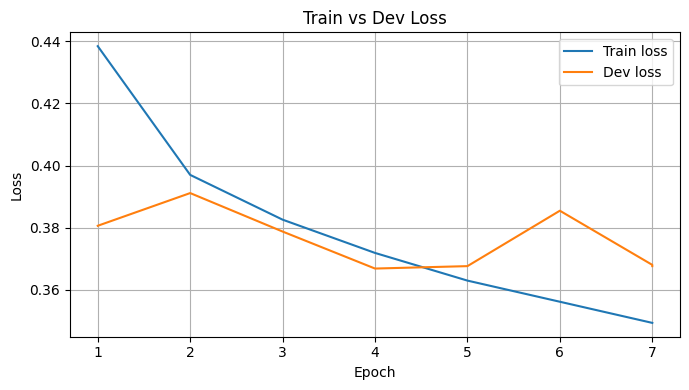

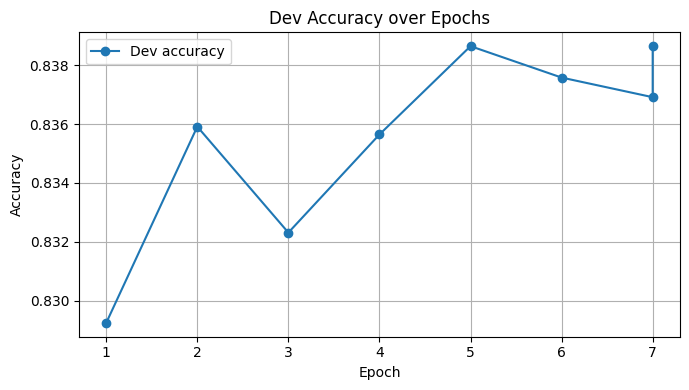

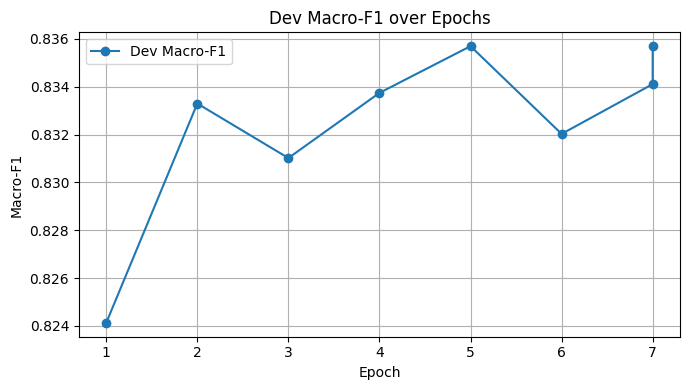

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Separate train and eval logs
train_logs = eval_logs[eval_logs["loss"].notna()]
eval_logs_only = eval_logs[eval_logs["eval_loss"].notna()]

# ---------- 1. Train vs Dev Loss ----------
plt.figure(figsize=(7,4))
plt.plot(train_logs["epoch"], train_logs["loss"], label="Train loss")
plt.plot(eval_logs_only["epoch"], eval_logs_only["eval_loss"], label="Dev loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Dev Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------- 2. Train vs Dev Accuracy ----------
# Trainer only logs eval_accuracy, so train accuracy is approximated
if "eval_accuracy" in eval_logs_only.columns:
    plt.figure(figsize=(7,4))
    plt.plot(
        eval_logs_only["epoch"],
        eval_logs_only["eval_accuracy"],
        marker="o",
        label="Dev accuracy"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Dev Accuracy over Epochs")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No accuracy logged (expected if using F1 only).")

# ---------- 3. Train vs Dev Macro-F1 ----------
plt.figure(figsize=(7,4))
plt.plot(
    eval_logs_only["epoch"],
    eval_logs_only["eval_f1"],
    marker="o",
    label="Dev Macro-F1"
)
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Dev Macro-F1 over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Comparison with other Models from previous assignments

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import DataCollatorWithPadding

class BERTWrapper:
    def __init__(self, model, tokenizer, batch_size=32, device="cuda"):
        """
        Wrap a HuggingFace BERT model for easy prediction.

        Args:
            model: Pretrained BERT model (nn.Module)
            tokenizer: HuggingFace tokenizer
            batch_size: Batch size for predictions
            device: "cuda" or "cpu"
        """
        self.model = model.to(device).eval()
        self.tokenizer = tokenizer
        self.batch_size = batch_size
        self.device = device

        # Optional: use a collator if you want dynamic padding
        self.data_collator = DataCollatorWithPadding(
            tokenizer=self.tokenizer,
            padding=True,
            return_tensors="pt"
        )

    def _make_loader(self, texts):
        """
        Convert raw text into a DataLoader of tokenized inputs.
        """
        # Tokenize texts and return PyTorch tensors directly
        encodings = self.tokenizer(
            texts,
            truncation=True,
            padding=True,      # pad sequences to the longest in the batch
            return_tensors="pt"
        )

        # Wrap tensors into a Dataset
        dataset = TensorDataset(
            encodings["input_ids"],
            encodings["attention_mask"]
        )

        # Create DataLoader
        loader = DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=False
        )
        return loader

    def _predict_logits(self, texts):
        """
        Predict raw logits for a list of texts.
        """
        loader = self._make_loader(texts)
        all_logits = []

        with torch.no_grad():
            for batch in loader:
                input_ids, attention_mask = [b.to(self.device) for b in batch]
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                all_logits.append(outputs.logits.cpu())

        return torch.cat(all_logits, dim=0)

    def predict(self, texts):
        """
        Predict class labels for a list of texts.
        """
        logits = self._predict_logits(texts)
        return torch.argmax(logits, dim=1).numpy()

    def predict_proba(self, texts):
        """
        Predict class probabilities for a list of texts.
        """
        logits = self._predict_logits(texts)
        return torch.softmax(logits, dim=1).numpy()



best_bert_model = trainer.model
bert_clf = BERTWrapper(model=best_bert_model, tokenizer=tokenizer, batch_size=BATCH_SIZE, device=device)

In [ ]:
import gc

label_order = [0, 1]  # Negative, Positive

train_rows = []
dev_rows = []
test_rows = []

# Baseline
baseline.fit(x_train, y_train)  # baseline works on raw text, ok
y_train_pred_b = baseline.predict(x_train)
y_dev_pred_b   = baseline.predict(x_dev)
y_test_pred_b  = baseline.predict(x_test)

y_train_proba_b = baseline.predict_proba(x_train)
y_dev_proba_b   = baseline.predict_proba(x_dev)
y_test_proba_b  = baseline.predict_proba(x_test)

train_rows.append(make_results_row("Baseline", y_train, y_train_pred_b, y_train_proba_b, label_order))
dev_rows.append(make_results_row("Baseline",   y_dev,   y_dev_pred_b,   y_dev_proba_b,   label_order))
test_rows.append(make_results_row("Baseline",  y_test,  y_test_pred_b,  y_test_proba_b,  label_order))

del y_train_pred_b, y_dev_pred_b, y_test_pred_b
del y_train_proba_b, y_dev_proba_b, y_test_proba_b
gc.collect()

## TF-IDF + LR (best from assg 2)
best_lr.fit(x_train, y_train)
y_train_pred_lr = best_lr.predict(x_train)
y_dev_pred_lr   = best_lr.predict(x_dev)
y_test_pred_lr  = best_lr.predict(x_test)

y_train_proba_lr = best_lr.predict_proba(x_train)
y_dev_proba_lr   = best_lr.predict_proba(x_dev)
y_test_proba_lr  = best_lr.predict_proba(x_test)

train_rows.append(make_results_row("TF-IDF+LR", y_train, y_train_pred_lr, y_train_proba_lr, label_order))
dev_rows.append(make_results_row("TF-IDF+LR",   y_dev,   y_dev_pred_lr,   y_dev_proba_lr,   label_order))
test_rows.append(make_results_row("TF-IDF+LR",  y_test,  y_test_pred_lr,  y_test_proba_lr,  label_order))

del y_train_pred_lr, y_dev_pred_lr, y_test_pred_lr
del y_train_proba_lr, y_dev_proba_lr, y_test_proba_lr
gc.collect()

## MLP (on SVD features)
y_train_pred_m = mlp_clf.predict(X_train_svd)
y_dev_pred_m   = mlp_clf.predict(X_dev_svd)
y_test_pred_m  = mlp_clf.predict(X_test_svd)

y_train_proba_m = mlp_clf.predict_proba(X_train_svd)
y_dev_proba_m   = mlp_clf.predict_proba(X_dev_svd)
y_test_proba_m  = mlp_clf.predict_proba(X_test_svd)

train_rows.append(make_results_row("MLP", y_train, y_train_pred_m, y_train_proba_m, label_order))
dev_rows.append(make_results_row("MLP",   y_dev,   y_dev_pred_m,   y_dev_proba_m,   label_order))
test_rows.append(make_results_row("MLP",  y_test,  y_test_pred_m,  y_test_proba_m,  label_order))

#del X_train_svd, X_dev_svd, X_test_svd
del y_train_pred_m, y_dev_pred_m, y_test_pred_m
del y_train_proba_m, y_dev_proba_m, y_test_proba_m
#del mlp_clf
#del best_model_mlp
gc.collect()

# RNN

y_train_pred_rnn = rnn_clf.predict(train_clean_x)
y_dev_pred_rnn   = rnn_clf.predict(dev_clean_x)
y_test_pred_rnn  = rnn_clf.predict(test_clean_x)

y_train_proba_rnn = rnn_clf.predict_proba(train_clean_x)
y_dev_proba_rnn   = rnn_clf.predict_proba(dev_clean_x)
y_test_proba_rnn  = rnn_clf.predict_proba(test_clean_x)

train_rows.append(make_results_row("BiLSTM", train_clean_y, y_train_pred_rnn, y_train_proba_rnn, label_order))
dev_rows.append(make_results_row("BiLSTM",   dev_clean_y,   y_dev_pred_rnn,   y_dev_proba_rnn,   label_order))
test_rows.append(make_results_row("BiLSTM",  test_clean_y,  y_test_pred_rnn,  y_test_proba_rnn,  label_order))

del y_train_pred_rnn, y_dev_pred_rnn, y_test_pred_rnn
del y_train_proba_rnn, y_dev_proba_rnn, y_test_proba_rnn
#del rnn_clf
#del best_model_rnn
gc.collect()

# CNN

y_train_pred_cnn = cnn_clf.predict(train_clean_x)
y_dev_pred_cnn   = cnn_clf.predict(dev_clean_x)
y_test_pred_cnn  = cnn_clf.predict(test_clean_x)

y_train_proba_cnn = cnn_clf.predict_proba(train_clean_x)
y_dev_proba_cnn   = cnn_clf.predict_proba(dev_clean_x)
y_test_proba_cnn  = cnn_clf.predict_proba(test_clean_x)

train_rows.append(make_results_row("CNN", train_clean_y, y_train_pred_cnn, y_train_proba_cnn, label_order))
dev_rows.append(make_results_row("CNN",   dev_clean_y,   y_dev_pred_cnn,   y_dev_proba_cnn,   label_order))
test_rows.append(make_results_row("CNN",  test_clean_y,  y_test_pred_cnn,  y_test_proba_cnn,  label_order))

del y_train_pred_cnn, y_dev_pred_cnn, y_test_pred_cnn
del y_train_proba_cnn, y_dev_proba_cnn, y_test_proba_cnn
#del cnn_clf
#del trained_model_cnn
gc.collect()

# BERT

y_train_pred_bert = bert_clf.predict(x_train_bert)
y_dev_pred_bert   = bert_clf.predict(x_dev_bert)
y_test_pred_bert  = bert_clf.predict(x_test_bert)

y_train_proba_bert = bert_clf.predict_proba(x_train_bert)
y_dev_proba_bert   = bert_clf.predict_proba(x_dev_bert)
y_test_proba_bert  = bert_clf.predict_proba(x_test_bert)

train_rows.append(make_results_row("BERT + LoRA", y_train_bert, y_train_pred_bert, y_train_proba_bert, label_order))
dev_rows.append(make_results_row("BERT + LoRA",   y_dev_bert,   y_dev_pred_bert,   y_dev_proba_bert,   label_order))
test_rows.append(make_results_row("BERT + LoRA",  y_test_bert,  y_test_pred_bert,  y_test_proba_bert,  label_order))

del y_train_pred_bert, y_dev_pred_bert, y_test_pred_bert
del y_train_proba_bert, y_dev_proba_bert, y_test_proba_bert
#del bert_clf

# free GPU memory
#del best_bert_model
gc.collect()
#torch.cuda.empty_cache()

#################################################

cols = ["Model"]
for lbl in label_order:
    cols += [f"P({lbl})", f"R({lbl})", f"F1({lbl})", f"PR-AUC({lbl})"]
cols += ["Macro-P", "Macro-R", "Macro-F1", "Macro-PR-AUC"]

train_df = pd.DataFrame(train_rows)[cols]
dev_df   = pd.DataFrame(dev_rows)[cols]
test_df  = pd.DataFrame(test_rows)[cols]

print("=== TRAIN RESULTS ===")
display(train_df)
print("\n=== DEV RESULTS ===")
display(dev_df)
print("\n=== TEST RESULTS ===")
display(test_df)


=== TRAIN RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.000000,0.000000,0.000000,0.435364,0.564636,1.000000,0.721747,0.564636,0.282318,0.500000,0.360874,0.500000
1,TF-IDF+LR,0.800657,0.831846,0.815953,0.884331,0.866329,0.840309,0.853121,0.934591,0.833493,0.836077,0.834537,0.909461
2,MLP,0.825968,0.690601,0.752243,0.860903,0.788201,0.887804,0.835043,0.906844,0.807084,0.789202,0.793643,0.883873
3,BiLSTM,0.846344,0.881285,0.863461,0.929839,0.905463,0.876642,0.890819,0.959860,0.875903,0.878963,0.877140,0.944850
4,CNN,0.802078,0.859901,0.829983,0.898172,0.885628,0.836403,0.860312,0.942985,0.843853,0.848152,0.845148,0.920578
5,BERT + LoRA,0.859053,0.849468,0.854234,0.930197,0.884922,0.892535,0.888713,0.954604,0.871988,0.871002,0.871473,0.942400



=== DEV RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.000000,0.000000,0.000000,0.435391,0.564609,1.000000,0.721725,0.564609,0.282304,0.500000,0.360863,0.500000
1,TF-IDF+LR,0.735910,0.763859,0.749624,0.814233,0.812409,0.788616,0.800336,0.881390,0.774160,0.776238,0.774980,0.847811
2,MLP,0.707028,0.594640,0.645982,0.739800,0.721544,0.809991,0.763214,0.822055,0.714286,0.702315,0.704598,0.780927
3,BiLSTM,0.737275,0.757459,0.747231,0.819064,0.808825,0.791741,0.800192,0.880489,0.773050,0.774600,0.773711,0.849777
4,CNN,0.719030,0.765918,0.741734,0.809184,0.809821,0.769076,0.788923,0.876072,0.764426,0.767497,0.765328,0.842628
5,BERT + LoRA,0.818111,0.809342,0.813703,0.895644,0.854181,0.861242,0.857697,0.931772,0.836146,0.835292,0.835700,0.913708



=== TEST RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.000000,0.000000,0.000000,0.435362,0.564638,1.000000,0.721749,0.564638,0.282319,0.500000,0.360874,0.500000
1,TF-IDF+LR,0.731323,0.754058,0.742517,0.817475,0.805710,0.786397,0.795937,0.880550,0.768517,0.770228,0.769227,0.849012
2,MLP,0.707851,0.589587,0.643329,0.746715,0.719665,0.812375,0.763215,0.821697,0.713758,0.700981,0.703272,0.784206
3,BiLSTM,0.740409,0.751693,0.746009,0.819974,0.806525,0.797060,0.801765,0.879283,0.773467,0.774377,0.773887,0.849628
4,CNN,0.725971,0.756927,0.741126,0.814234,0.806471,0.779991,0.793010,0.876709,0.766221,0.768459,0.767068,0.845472
5,BERT + LoRA,0.824520,0.802297,0.813257,0.898605,0.850665,0.868343,0.859413,0.927978,0.837593,0.835320,0.836335,0.913291


## prompting a large LLM

In [ ]:
import random
random.seed(2026)

def sample_train_tweets():
  i = random.randint(0, len(x_train_bert) - 1)
  return { "text" : x_train_bert[i], "label" : str(y_train_bert[i]) }

def sample_test_tweets():
  i = random.randint(0, len(x_test_bert) - 1)
  return { "text" : x_test_bert[i], "label" : str(y_test_bert[i]) }


def tweet_to_text(tweet):
  return f"""Tweet: {tweet["text"]}
  Sentiment: {tweet["label"]}

  """

def build_first_llm_prompt(num_of_examples=10):
  prompt = """
  You are going to Classify the sentiment of the following tweets as Positive or Negative.

  When i tweet is Negative you respond only with 0 and 1 if Positive, and Nothing else.

  Examples:

  """
  for _ in range(0, num_of_examples):
    prompt += tweet_to_text(sample_train_tweets())
  return prompt


def build_llm_promt_for(tweet):
  prompt = f"""
  Classify the sentiment of the following tweet, respond only with 0 and 1 if Positive, and Nothing else.

  Tweet Text: {tweet["text"]}
  """
  return prompt


print("==============First Prompt======================")
print(build_first_llm_prompt(10))
print("================================================")

test_tweets = [sample_test_tweets() for _ in range(0, 10)]

for tweet in test_tweets:
  print(build_llm_promt_for(tweet))
  print("(DO NOT COPPY) Real: " + tweet["label"])
  print("================================================")


llm_predictions = {
    0: 0,  # ChatGPT prediction for test_tweets[0]
    1: 1,
    2: 1,
    3: 1,
    4: 1,
    5: 1,
    6: 0,
    7: 0,
    8: 0,
    9: 1
}

y_true = [int(tweet["label"]) for tweet in test_tweets]
y_pred = [llm_predictions[i] for i in range(len(test_tweets))]

print("ChatGPT Accuracy:", accuracy_score(y_true, y_pred)) # 0.9 ---> only one mistake
print("ChatGPT Macro-F1:", f1_score(y_true, y_pred, average="macro"))

pd.DataFrame({
    "Tweet": [t["text"] for t in test_tweets],
    "Gold": y_true,
    "ChatGPT": y_pred
})

==============First Prompt======================

  You are going to Classify the sentiment of the following tweets as Positive or Negative.

  When i tweet is Negative you respond only with 0 and 1 if Positive, and Nothing else.

  Examples:

  Tweet: @ChrisAGriffin unfortunately some of our &quot;other&quot; teams don't have as much pull 
  Sentiment: 0

  Tweet: @ashleysmith yay!  
  Sentiment: 1

  Tweet: @alexmace Oh yeah 
  Sentiment: 1

  Tweet: @britneyspears ur so amazing , every one in scotland loves u 
  Sentiment: 1

  Tweet: @Chassit  why don't they shut down the  internet completely, would be more efficient 
  Sentiment: 0

  Tweet: @a_dorkable so what there's 3 of us and one of them. 
  Sentiment: 1

  Tweet: @ashley_rose sorry. 
  Sentiment: 0

  Tweet: @ashlizben I love shirley temples too!! Now I want one 
  Sentiment: 0

  Tweet: @alex_segura It's contagious! I've been that way all day. Just smoked half a cigarette.  Didn't help. Guess that's a plus.
  Sentiment: 0



,Tweet,Gold,ChatGPT
0,@BlaqueBeautiful yeah it is a strong word dont...,0,0
1,@Catholiccitizen rest well,1,1
2,@andrewmilton wow i see you left a barbershop ...,1,1
3,@bygbaby lol Sleep well hun. I am following s...,1,1
4,"@annkogut annaaaa! fez twitter quando, menin...",1,1
5,@bouska I want a #Noh8 Photo! #jealous!,0,1
6,"@alagerst yeah, you look kinda plaguey in gree...",0,0
7,:]...bored...just came back from a bike ride b...,0,0
8,#howarewe 3/10,0,0
9,@AnInspiredMind Your welcome,1,1
